# PBC2 joint model with an exponential baseline hazard

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

ROOT = Path.cwd().resolve()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

In [2]:
from jmstate.types import ModelData

torch.manual_seed(42)
pbc2 = pd.read_csv(ROOT / "data" / "pbc2.csv")
pbc2["sex"] = pbc2["sex"].map({"female": 0, "male": 1})
pbc2["drug"] = pbc2["drug"].map({"placebo": 0, "D-penicil": 1})
pbc2["serBilir"] = np.log(pbc2["serBilir"])

trajectories, censoring, times, markers, covariates = [], [], [], [], []
for _, group in pbc2.groupby("id", sort=True):
    event = int(group["status2"].iloc[0])
    event_time = float(group["years"].iloc[0]) / 10
    trajectory = [(0.0, 0)]
    if event:
        trajectory.append((event_time, 1))
    trajectories.append(trajectory)
    censoring.append(max(event_time, float(group["year"].max()) / 10))
    times.append(torch.tensor(group["year"].to_numpy(), dtype=torch.float32) / 10)
    marker = group[["prothrombin", "serBilir"]].to_numpy()
    markers.append(torch.tensor(marker, dtype=torch.float32))
    covariate = group[["sex", "drug"]].iloc[0].to_numpy()
    covariates.append(torch.tensor(covariate, dtype=torch.float32))

pad = nn.utils.rnn.pad_sequence
data = ModelData(
    torch.stack(covariates),
    pad(times, batch_first=True, padding_value=torch.nan),
    pad(markers, batch_first=True, padding_value=torch.nan),
    trajectories,
    torch.tensor(censoring, dtype=torch.float32)[:, None],
)

In [3]:
from jmstate.functions.base_hazards import Exponential
from jmstate.types import ModelDesign, ModelParameters, PrecisionParameters

DIM = 2


def indiv_params_fn(fixed: torch.Tensor, _x: torch.Tensor, b: torch.Tensor):
    return fixed[None, :] + b


def regression_fn(t: torch.Tensor, indiv_params: torch.Tensor):
    t = t.view(*([1] * (indiv_params.ndim - 2)), *t.shape, 1)
    return t * indiv_params[..., None, -DIM:] + indiv_params[..., None, :DIM]


def initial_fixed_effects(data: ModelData):
    estimates = []
    for marker in range(DIM):
        valid = torch.isfinite(data.t) & torch.isfinite(data.y[..., marker])
        x = torch.stack((torch.ones_like(data.t[valid]), data.t[valid]), dim=1)
        estimates.append(torch.linalg.lstsq(x, data.y[..., marker][valid]).solution)
    estimates = torch.stack(estimates)
    return torch.cat((estimates[:, 0], estimates[:, 1]))


marker_center = torch.nanmean(data.y, dim=(0, 1))


def centered_regression_fn(t: torch.Tensor, indiv_params: torch.Tensor):
    return regression_fn(t, indiv_params) - marker_center


design = ModelDesign(
    indiv_params_fn, regression_fn, {(0, 1): centered_regression_fn}
)
params = ModelParameters(
    initial_fixed_effects(data),
    PrecisionParameters.from_covariance(torch.eye(2 * DIM), "diag"),
    PrecisionParameters.from_covariance(torch.eye(DIM), "spherical"),
    {(0, 1): Exponential(0.1)},
    {(0, 1): torch.zeros(DIM)},
    {(0, 1): torch.zeros(2)},
)

In [4]:
from jmstate import MultiStateJointModel

torch.manual_seed(42)
optimizer = torch.optim.Adam(params.parameters(), lr=0.01)
model = MultiStateJointModel(
    design,
    params,
    optimizer,
    max_iter=10000,
    window_size=500,
    n_chains=5,
    n_subsample=10,
).fit(data)


Fitting joint model:   0%|          | 0/10000 [00:00<?, ?it/s]


Fitting joint model:   0%|          | 3/10000 [00:00<05:50, 28.56it/s]


Fitting joint model:   0%|          | 6/10000 [00:00<05:44, 29.01it/s]


Fitting joint model:   0%|          | 9/10000 [00:00<05:58, 27.87it/s]


Fitting joint model:   0%|          | 12/10000 [00:00<06:02, 27.54it/s]

...


Fitting joint model:  10%|▉         | 967/10000 [00:30<04:40, 32.18it/s]


Fitting joint model:  10%|▉         | 971/10000 [00:30<04:41, 32.10it/s]


Fitting joint model:  10%|▉         | 975/10000 [00:30<04:40, 32.14it/s]


Fitting joint model:  10%|▉         | 979/10000 [00:30<04:42, 31.99it/s]


Fitting joint model:  10%|▉         | 982/10000 [00:30<04:43, 31.84it/s]


Computing FIM and Model Selection Criteria:   0%|          | 0/100 [00:00<?, ?it/s]


Computing FIM and Model Selection Criteria:   2%|▏         | 2/100 [00:00<00:07, 13.60it/s]


Computing FIM and Model Selection Criteria:   5%|▌         | 5/100 [00:00<00:05, 17.62it/s]


Computing FIM and Model Selection Criteria:   8%|▊         | 8/100 [00:00<00:04, 19.03it/s]


Computing FIM and Model Selection Criteria:  11%|█         | 11/100 [00:00<00:04, 19.67it/s]

...


Computing FIM and Model Selection Criteria:  92%|█████████▏| 92/100 [00:04<00:00, 20.72it/s]


Computing FIM and Model Selection Criteria:  95%|█████████▌| 95/100 [00:04<00:00, 20.48it/s]


Computing FIM and Model Selection Criteria:  98%|█████████▊| 98/100 [00:04<00:00, 20.57it/s]


Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:04<00:00, 20.51it/s]

╭──────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │ 10.551 │     0.090      │ 117.137 │  0.000  │        ***         │ │
│ │ fixed_effects[1]                │ 0.518  │     0.087      │  5.952  │  0.000  │        ***         │ │
│ │ fixed_effects[2]                │ 2.800  │     0.483      │  5.792  │  0.000  │        ***         │ │
│ │ fixed_effects[3]                │ 1.339  │     0.150      │  8.945  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]             │ 0.124  │     0.044      │  2.794  │  0.005  │         **         │ │
│ │ random_prec.flat[1]             │ -0.000 │     0.073      │  0.004  │  0.997  │                    │ │
│ │ random_prec.flat[2]             │ -1.417 │     0.042      │ 33.395  │  0.000  │        ***         │ │
│ │ random_prec.flat[3]             │ -0.163 │     0.135      │  1.209  │  0.227  │                    │ │
│ │ noise_prec.flat[0]              │ 0.266  │     0.002      │ 122.682 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.419 │     0.233      │  6.079  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │ 0.211  │     0.057      │  3.726  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[1]            │ 1.298  │     0.141      │  9.202  │  0.000  │        ***         │ │
│ │ x_coefs.(0, 1)[0]               │ 0.354  │     0.268      │  1.322  │  0.186  │                    │ │
│ │ x_coefs.(0, 1)[1]               │ -0.038 │     0.198      │  0.190  │  0.849  │                    │ │
│ └─────────────────────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -5601.774                                                                              │
│ AIC: 11231.548                                                                                         │
│ BIC: 11276.958                                                                                         │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

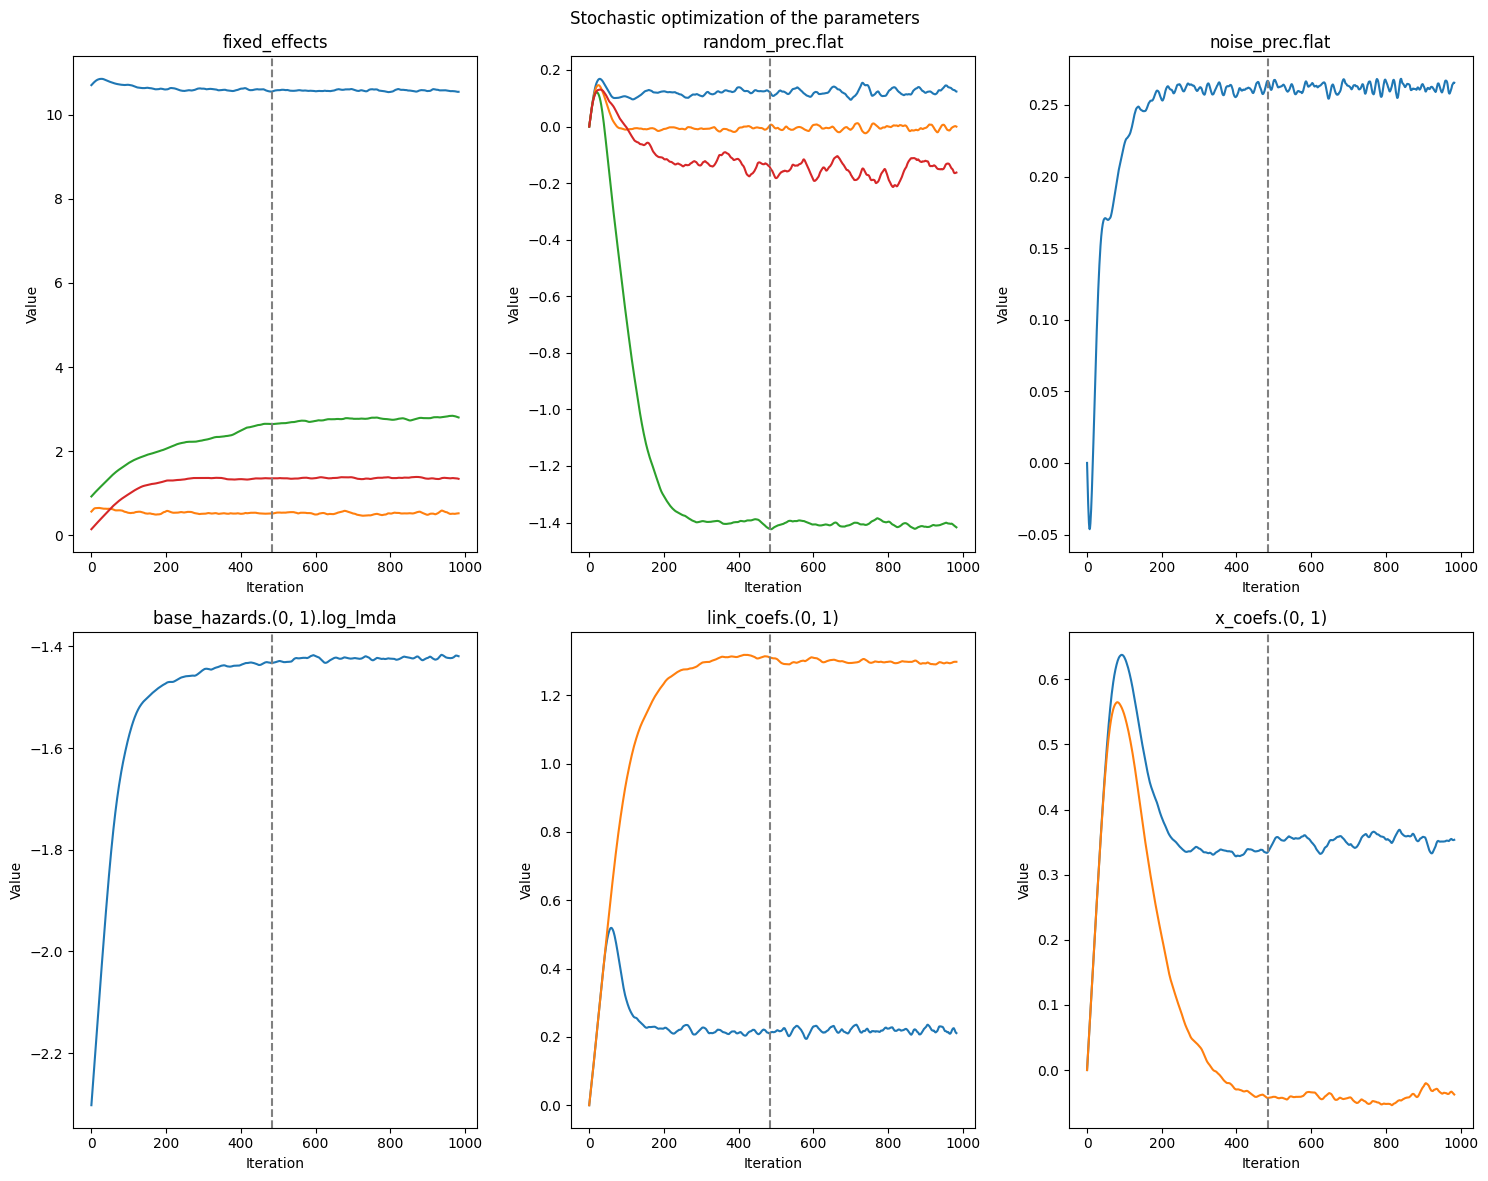

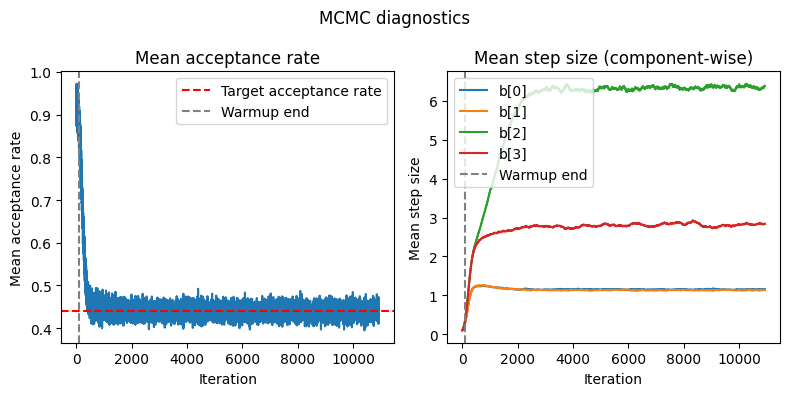

In [5]:
from jmstate.utils import plot_mcmc_diagnostics, plot_params_history

model.compute_summary().summary()

figure, axes = plot_params_history(model, figsize=(15, 12))
convergence = len(model.params_history_) - model.window_size
for axis in axes:
    axis.axvline(convergence, color="gray", linestyle="--")
    if axis.get_legend() is not None:
        axis.get_legend().remove()
figure.savefig(ROOT / "figures" / "pbc2-exponential-optimization.pdf")
plt.show()

figure, _ = plot_mcmc_diagnostics(model)
figure.savefig(ROOT / "figures" / "pbc2-exponential-diagnostics.pdf")
plt.show()